# Customer Segmentation - Data Preparation

## Objective

The purpose of this notebook is to prepare a clean and model-ready dataset for customer segmentation.

The tasks performed in this notebook include:

- Loading engineered customer features
- Selecting relevant features for clustering
- Handling missing values
- Analyzing feature distributions
- Reducing skewness where appropriate
- Checking feature correlations
- Scaling numerical features
- Saving the prepared dataset for clustering

The output of this notebook will be used as the input for the K-Means clustering model.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

In [43]:
customer_df = pd.read_csv("../../data/processed/customer_features.csv", parse_dates=["first_purchase", "last_purchase"])

### Basic Dataset overview

In [44]:
customer_df.head()

,customer_unique_id,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,1.0,12.00,141.90,5.0,6.0,2018-05-10,2018-05-10,0,116,1.0,0.084567,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,1.0,8.29,27.19,4.0,3.0,2018-05-07,2018-05-07,0,119,1.0,0.304892,4,1,1,411
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,17.22,86.22,3.0,26.0,2017-03-10,2017-03-10,0,542,1.0,0.199722,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,1.0,17.63,43.62,4.0,20.0,2017-10-12,2017-10-12,0,326,1.0,0.404172,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,1.0,16.89,196.89,5.0,13.0,2017-11-14,2017-11-14,0,293,1.0,0.085784,2,1,4,214


In [45]:
print("Shape :", customer_df.shape)

Shape : (95419, 18)


In [46]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95419 entries, 0 to 95418
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_unique_id      95419 non-null  str           
 1   total_orders            95419 non-null  int64         
 2   total_spent             95419 non-null  float64       
 3   total_products          95419 non-null  float64       
 4   total_freight_paid      95419 non-null  float64       
 5   avg_order_value         95419 non-null  float64       
 6   avg_review_score        94720 non-null  float64       
 7   avg_delivery_days       93355 non-null  float64       
 8   first_purchase          95419 non-null  datetime64[us]
 9   last_purchase           95419 non-null  datetime64[us]
 10  customer_lifetime_days  95419 non-null  int64         
 11  recency_days            95419 non-null  int64         
 12  avg_basket_size         95419 non-null  float64       
 1

In [47]:
customer_df.describe()

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,R_score,F_score,M_score,RFM_score
count,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,94720.000000,93355.000000,95419,95419,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000
mean,1.034018,166.070491,1.180551,23.600133,161.073799,4.102521,12.506692,2017-12-30 19:40:56.529622,2018-01-02 12:05:03.788553,2.683417,243.496484,1.139081,0.207910,3.004098,1.033746,2.999707,313.746937
min,1.000000,9.590000,1.000000,0.000000,9.590000,1.000000,0.000000,2016-09-04 00:00:00,2016-09-04 00:00:00,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,111.000000
25%,1.000000,63.100000,1.000000,14.080000,62.440000,4.000000,7.000000,2017-09-12 00:00:00,2017-09-15 00:00:00,0.000000,119.000000,1.000000,0.116290,2.000000,1.000000,2.000000,212.000000
50%,1.000000,107.950000,1.000000,17.600000,105.780000,5.000000,10.000000,2018-01-19 00:00:00,2018-01-22 00:00:00,0.000000,224.000000,1.000000,0.182941,3.000000,1.000000,3.000000,313.000000
75%,1.000000,183.270000,1.000000,25.540000,177.150000,5.000000,16.000000,2018-05-04 00:00:00,2018-05-07 00:00:00,0.000000,353.000000,1.000000,0.274264,4.000000,1.000000,4.000000,414.000000
max,16.000000,13664.080000,24.000000,1794.960000,13664.080000,5.000000,210.000000,2018-08-29 00:00:00,2018-09-03 00:00:00,633.000000,729.000000,21.000000,0.955451,5.000000,5.000000,5.000000,555.000000
std,0.211235,228.341907,0.621425,22.878731,221.208569,1.326359,9.554535,NaN,NaN,25.263205,153.153950,0.526848,0.124982,1.414071,0.202101,1.414369,141.500858


In [48]:
customer_df.isnull().sum()

customer_unique_id           0
total_orders                 0
total_spent                  0
total_products               0
total_freight_paid           0
avg_order_value              0
avg_review_score           699
avg_delivery_days         2064
first_purchase               0
last_purchase                0
customer_lifetime_days       0
recency_days                 0
avg_basket_size              0
freight_ratio                0
R_score                      0
F_score                      0
M_score                      0
RFM_score                    0
dtype: int64

## Feature Selection

Only behavioral features that describe customer purchasing patterns are selected.

The following columns are excluded:

- `customer_unique_id` → Identifier, contains no predictive information.
- `first_purchase` → Already represented through customer lifetime.
- `last_purchase` → Already represented through recency.
- `RFM_score` → String representation of R, F and M scores.
- `R_score`, `F_score`, `M_score` → Excluded initially because they are discretized versions of continuous variables already included in the dataset.

In [49]:
segmentation_df = customer_df[
    [
        "total_orders",
        "total_spent",
        "total_products",
        "total_freight_paid",
        "avg_order_value",
        "avg_review_score",
        "avg_delivery_days",
        "customer_lifetime_days",
        "recency_days",
        "avg_basket_size",
        "freight_ratio",
    ]
].copy()

In [50]:
segmentation_df.head()

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio
0,1,141.90,1.0,12.00,141.90,5.0,6.0,0,116,1.0,0.084567
1,1,27.19,1.0,8.29,27.19,4.0,3.0,0,119,1.0,0.304892
2,1,86.22,1.0,17.22,86.22,3.0,26.0,0,542,1.0,0.199722
3,1,43.62,1.0,17.63,43.62,4.0,20.0,0,326,1.0,0.404172
4,1,196.89,1.0,16.89,196.89,5.0,13.0,0,293,1.0,0.085784


### Missing Value Analysis

In [51]:
segmentation_df.isnull().sum()

total_orders                 0
total_spent                  0
total_products               0
total_freight_paid           0
avg_order_value              0
avg_review_score           699
avg_delivery_days         2064
customer_lifetime_days       0
recency_days                 0
avg_basket_size              0
freight_ratio                0
dtype: int64

In [52]:
missing = (
    segmentation_df.isnull()
    .mean()
    .mul(100)
    .round(2)
)

missing[missing > 0]

avg_review_score     0.73
avg_delivery_days    2.16
dtype: float64

In [53]:
segmentation_df[
    segmentation_df["avg_review_score"].isna()
].head()

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio
44,1,116.23,1.0,16.33,116.23,NaN,NaN,0,301,1.0,0.140497
287,1,673.69,1.0,23.79,673.69,NaN,26.0,0,290,1.0,0.035313
376,1,92.57,1.0,13.57,92.57,NaN,14.0,0,257,1.0,0.146592
875,1,1898.61,1.0,110.61,1898.61,NaN,12.0,0,17,1.0,0.058258
970,1,532.49,1.0,30.49,532.49,NaN,NaN,0,26,1.0,0.057259


In [54]:
segmentation_df[
    segmentation_df["avg_delivery_days"].isna()
].head()

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio
44,1,116.23,1.0,16.33,116.23,NaN,NaN,0,301,1.0,0.140497
58,1,52.38,1.0,12.48,52.38,2.0,NaN,0,305,1.0,0.238259
234,1,91.29,1.0,14.29,91.29,5.0,NaN,0,291,1.0,0.156534
306,1,55.06,1.0,17.06,55.06,1.0,NaN,0,168,1.0,0.309844
355,1,420.94,1.0,21.04,420.94,1.0,NaN,0,387,1.0,0.049983


#### create a seperate indicator :
has_review

0 = No Review

1 = Reviewed

In [55]:
segmentation_df["has_review"] = (
    segmentation_df["avg_review_score"]
    .notna()
    .astype(int)
)

segmentation_df["avg_review_score"] = (
    segmentation_df["avg_review_score"]
    .fillna(segmentation_df["avg_review_score"].median())
)

#### For avg_delivery_days: Add delivery_completed, then median imputation

In [56]:
segmentation_df["delivery_completed"] = (
    segmentation_df["avg_delivery_days"]
    .notna()
    .astype(int)
)

segmentation_df["avg_delivery_days"] = (
    segmentation_df["avg_delivery_days"]
    .fillna(segmentation_df["avg_delivery_days"].median())
)

In [57]:
segmentation_df["has_review"].value_counts()

has_review
1    94720
0      699
Name: count, dtype: int64

In [58]:
segmentation_df["delivery_completed"].value_counts()

delivery_completed
1    93355
0     2064
Name: count, dtype: int64

In [59]:
segmentation_df.isnull().sum()

total_orders              0
total_spent               0
total_products            0
total_freight_paid        0
avg_order_value           0
avg_review_score          0
avg_delivery_days         0
customer_lifetime_days    0
recency_days              0
avg_basket_size           0
freight_ratio             0
has_review                0
delivery_completed        0
dtype: int64

### Feature Distribution Analysis
To understand the distribution of each numerical feature before applying any transformation.


K-Means calculates distances between points. If some variables are extremely skewed, they can dominate the clustering process even after scaling.

#### Analyse  the Skewness

In [60]:
# Calculate skewness for all numerical features
skewness = segmentation_df.skew(numeric_only=True).sort_values(ascending=False)

skewness.to_frame(name="Skewness")

,Skewness
customer_lifetime_days,12.243044
total_freight_paid,11.623270
total_orders,11.441549
avg_order_value,9.278306
total_spent,9.086943
avg_basket_size,7.595266
total_products,7.410249
avg_delivery_days,3.930414
freight_ratio,1.069025
recency_days,0.448580


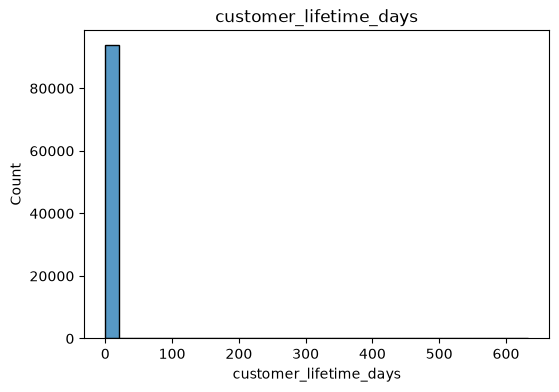

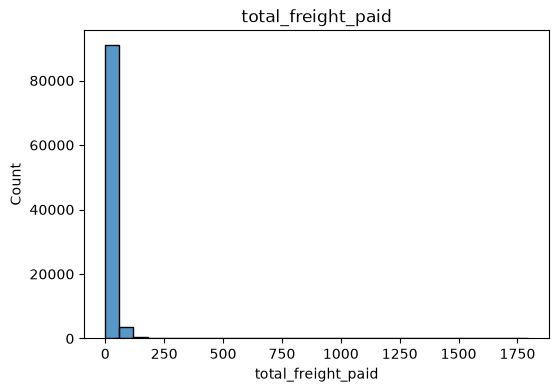

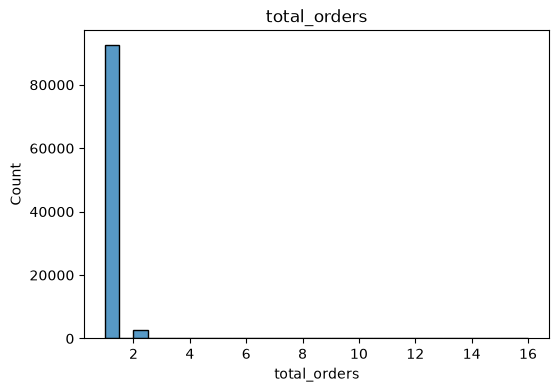

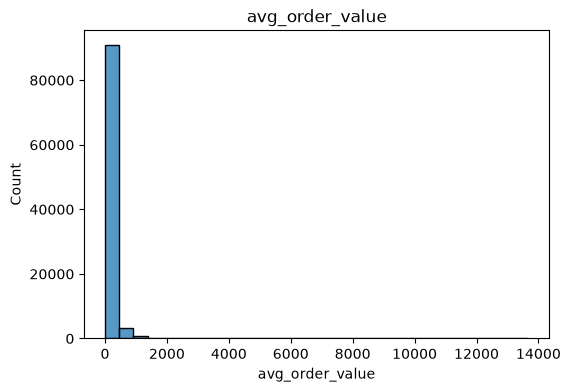

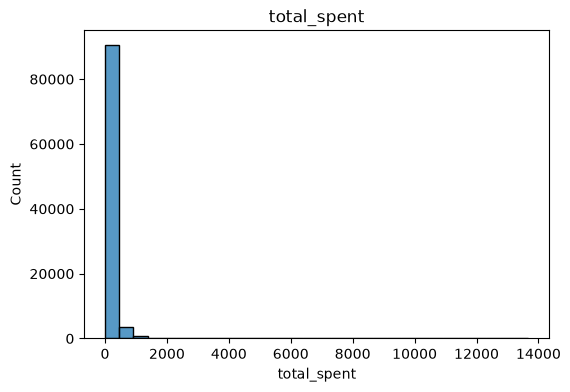

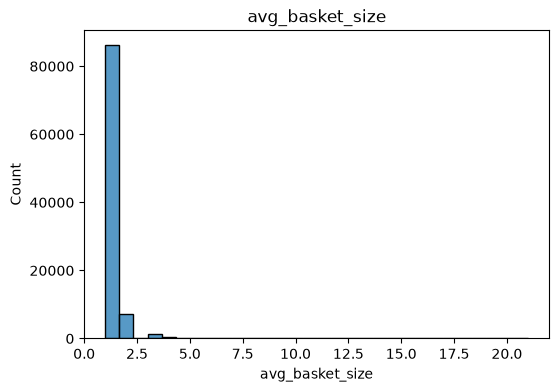

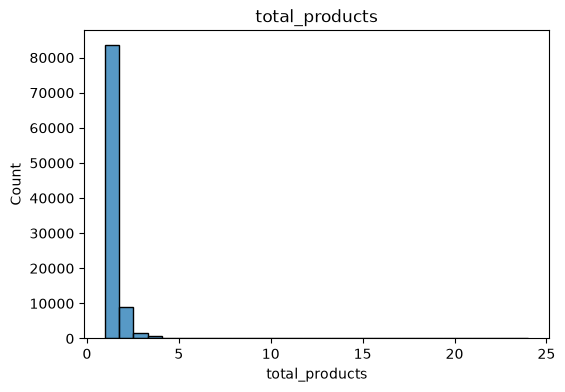

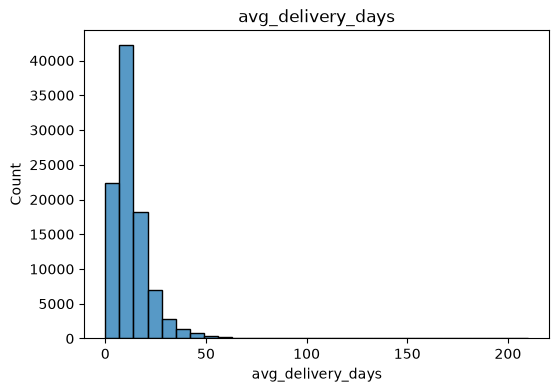

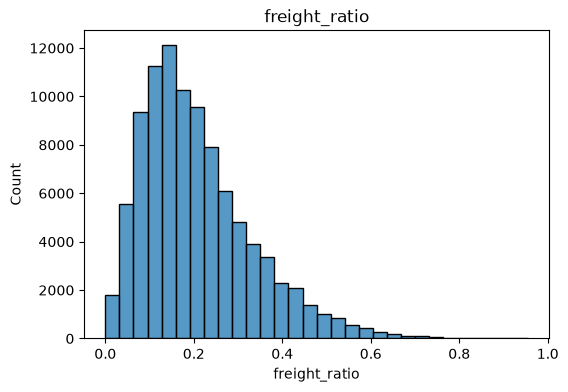

In [61]:
high_skew = skewness[skewness > 1].index

for col in high_skew:
    plt.figure(figsize=(6,4))
    sns.histplot(segmentation_df[col], bins=30)
    plt.title(col)
    plt.show()

### To remove the skewness, we perform log1() transformation

- Reduce Skewness

    Many real-world features (like income, transaction amounts, word counts) are highly skewed.

    Applying log1p() compresses large values and spreads out small ones, making the distribution closer to normal.

- Handle Zero Values

    Standard log(x) fails when x = 0.

    log1p() avoids this by shifting values by +1 before applying the log.

In [62]:
segmentation_df.head()

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,has_review,delivery_completed
0,1,141.90,1.0,12.00,141.90,5.0,6.0,0,116,1.0,0.084567,1,1
1,1,27.19,1.0,8.29,27.19,4.0,3.0,0,119,1.0,0.304892,1,1
2,1,86.22,1.0,17.22,86.22,3.0,26.0,0,542,1.0,0.199722,1,1
3,1,43.62,1.0,17.63,43.62,4.0,20.0,0,326,1.0,0.404172,1,1
4,1,196.89,1.0,16.89,196.89,5.0,13.0,0,293,1.0,0.085784,1,1


#### Variables to transform

In [64]:
log_features = [
    "total_spent",
    "total_freight_paid",
    "avg_order_value",
    "customer_lifetime_days",
    "avg_delivery_days"
]

#### Apply the transformation

In [65]:
for feature in log_features:
    segmentation_df[feature] = np.log1p(segmentation_df[feature])

#### Improvement verification

In [66]:
# Compare skewness before and after
before = customer_df[
    [
        "total_spent",
        "total_freight_paid",
        "avg_order_value",
        "customer_lifetime_days",
        "avg_delivery_days"
    ]
].skew()

after = segmentation_df[
    [
        "total_spent",
        "total_freight_paid",
        "avg_order_value",
        "customer_lifetime_days",
        "avg_delivery_days"
    ]
].skew()

comparison = pd.DataFrame({
    "Before": before,
    "After": after
})

comparison

,Before,After
total_spent,9.086943,0.533843
total_freight_paid,11.623270,0.469933
avg_order_value,9.278306,0.551902
customer_lifetime_days,12.243044,7.326937
avg_delivery_days,3.879708,-0.002258


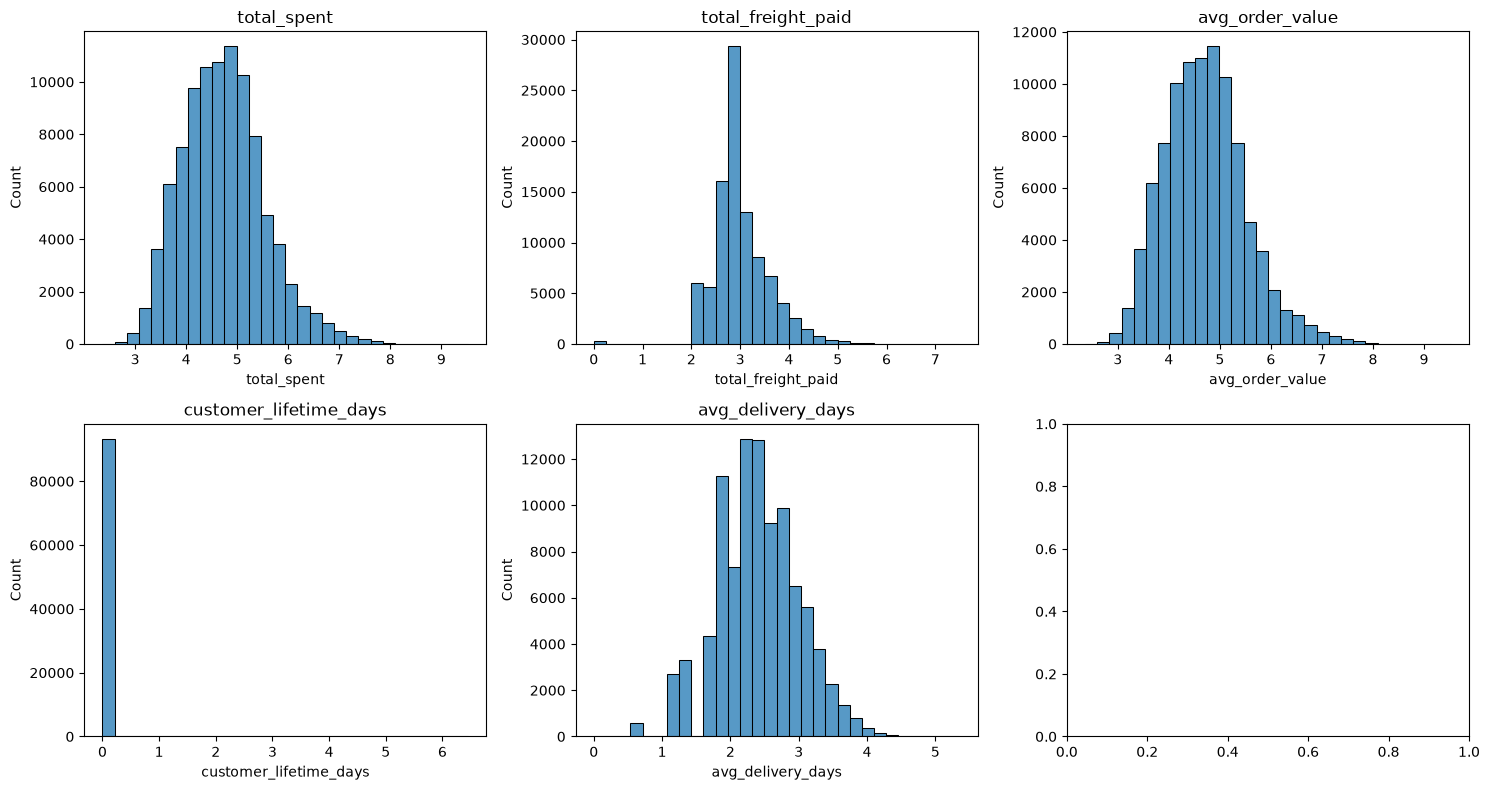

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(log_features):
    sns.histplot(segmentation_df[feature], bins=30, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

### Correlation Analysis

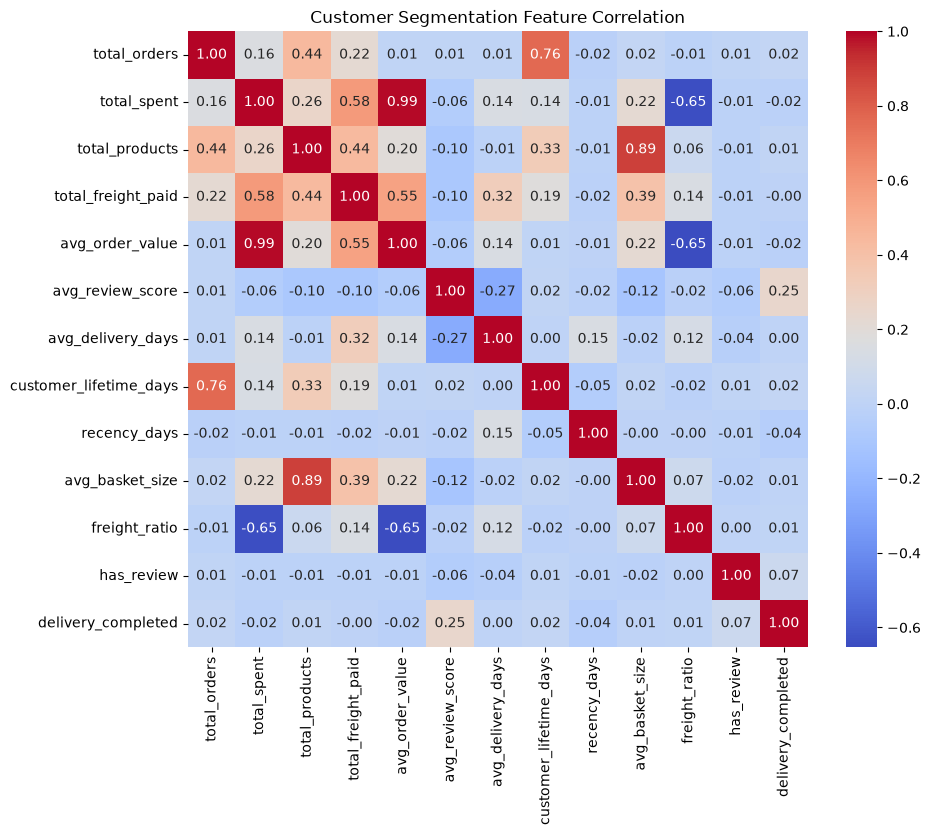

In [68]:
plt.figure(figsize=(10,8))

corr = segmentation_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Segmentation Feature Correlation")
plt.show()

##### Since the correlation between the avg_basket_size and the total product is 0.89 so decision is to remove the avg_basket_size and also remove the avg_order_value

### Variables to keep

In [70]:
selected_features = [
    "total_orders",
    "total_spent",
    "total_products",
    "total_freight_paid",
    "avg_review_score",
    "avg_delivery_days",
    "customer_lifetime_days",
    "recency_days",
    "freight_ratio",
    "has_review",
    "delivery_completed"
]

### Feature scaling

In [71]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scaled_data = scaler.fit_transform(segmentation_df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=segmentation_df.columns
)

scaled_df.head()

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,has_review,delivery_completed
0,0.0,0.256882,0.0,-0.633686,0.282194,0.0,-0.652077,0.0,-0.461538,0.0,-0.622723,0.0,0.0
1,0.0,-1.280280,0.0,-1.228097,-1.289843,-1.0,-1.459432,0.0,-0.448718,0.0,0.771965,0.0,0.0
2,0.0,-0.210667,0.0,-0.036516,-0.195962,-2.0,1.295456,0.0,1.358974,0.0,0.106225,0.0,0.0
3,0.0,-0.845400,0.0,0.002851,-0.845096,-1.0,0.932886,0.0,0.435897,0.0,1.400427,0.0,0.0
4,0.0,0.565195,0.0,-0.068850,0.597503,0.0,0.347923,0.0,0.294872,0.0,-0.615017,0.0,0.0


In [72]:
scaled_df.to_csv(
    "../../data/processed/customer_segmentation_dataset.csv",
    index=False
)